In [16]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

INPUT_SIZE = 28 * 28 
NUM_CLASSES = 10
BATCH_SIZE = 500 
EPOCHS = 50         
SEED = 42          

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='../data', train=True, transform=transform, download=False)
test_dataset = datasets.MNIST(root='../data', train=False, transform=transform, download=False)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

## Tweaking Learning Rate for OLNM

In [2]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

LEARNING_RATES = [2.0, 1.0, 0.5, 0.1, 0.05, 0.01, 0.005]
criterion = nn.MSELoss()
all_loss_histories = {}

for lr in LEARNING_RATES:
    print(f"--- Starting Training for OLNM with Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    from olnm import OLNM as ORIGINAL_OLNM
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = ORIGINAL_OLNM(model.parameters(), 
                              lr=lr, 
                              c=1000, 
                              batch_size=BATCH_SIZE,
                              )

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            def closure(grad=True):
                logits = model(data)
                output_probs = torch.softmax(logits, dim=1)
                target_one_hot = nn.functional.one_hot(target, num_classes=NUM_CLASSES).float()
                loss = criterion(output_probs, target_one_hot)
                if grad:
                    optimizer.zero_grad()
                    loss.backward()
                return loss

            loss = optimizer.step(closure)

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    all_loss_histories[lr] = loss_history

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")

# --- Save result ---
with open("results/olnm_lr.json", "w") as f:
    json.dump(all_loss_histories, f)

--- Starting Training for OLNM with Learning Rate: 2.0 ---
LR: 2.0, Epoch [1/5], Final Batch Loss: 0.02660
LR: 2.0, Epoch [2/5], Final Batch Loss: 0.02559
LR: 2.0, Epoch [3/5], Final Batch Loss: 0.02266
LR: 2.0, Epoch [4/5], Final Batch Loss: 0.02376
LR: 2.0, Epoch [5/5], Final Batch Loss: 0.01951
Final Accuracy for LR 2.0: 83.87%

--- Starting Training for OLNM with Learning Rate: 1.0 ---
LR: 1.0, Epoch [1/5], Final Batch Loss: 0.01474
LR: 1.0, Epoch [2/5], Final Batch Loss: 0.01141
LR: 1.0, Epoch [3/5], Final Batch Loss: 0.01048
LR: 1.0, Epoch [4/5], Final Batch Loss: 0.01041
LR: 1.0, Epoch [5/5], Final Batch Loss: 0.00836
Final Accuracy for LR 1.0: 92.73%

--- Starting Training for OLNM with Learning Rate: 0.5 ---
LR: 0.5, Epoch [1/5], Final Batch Loss: 0.01513
LR: 0.5, Epoch [2/5], Final Batch Loss: 0.01219
LR: 0.5, Epoch [3/5], Final Batch Loss: 0.01068
LR: 0.5, Epoch [4/5], Final Batch Loss: 0.01035
LR: 0.5, Epoch [5/5], Final Batch Loss: 0.00873
Final Accuracy for LR 0.5: 92.74%

## Tweaking C for OLNM

In [24]:
import math
import sys, os, json
sys.path.append(os.path.abspath('..'))

criterion = nn.MSELoss()
all_loss_histories = {}
EPOCHS = 5         
lr = 1.0
BATCH_SIZE = 500
# Ts = [50, 60, 80, 90, 100, 150, 200, 500, 1000]
Ts = [5, 10, 15, 20, 25, 30, 40]

# T = c / math.sqrt(batch_size)  # ROOT_DECAY 
for T in Ts:
    print(f"--- Starting Training for OLNM with T: {T} ---")
    torch.manual_seed(SEED)
    from mnist.ver2_olnm import OLNM as ORIGINAL_OLNM
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = ORIGINAL_OLNM(model.parameters(), lr=lr, c=T, batch_size=BATCH_SIZE)
    optimizer.internal_buffer = None

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            def closure(grad=True, data=data, target=target):
                logits = model(data)
                output_probs = torch.softmax(logits, dim=1)
                target_one_hot = nn.functional.one_hot(target, num_classes=NUM_CLASSES).float()
                loss = criterion(output_probs, target_one_hot)
                if grad:
                    optimizer.zero_grad()
                    loss.backward()
                return loss
            if optimizer.reset is True:
                data_s = data
                target_s = target
            loss = optimizer.step(lambda: closure(data=data_s, target=target_s))

            loss_history.append(loss.item())
        
        print(f"T: {T}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    all_loss_histories[T] = loss_history

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for T {T}: {100 * correct / total:.2f}%\n")

# --- Save result ---
with open("results/olnm_t_small.json", "w") as f:
    json.dump(all_loss_histories, f)

--- Starting Training for OLNM with T: 5 ---
T: 5, Epoch [1/5], Final Batch Loss: 0.01374
T: 5, Epoch [2/5], Final Batch Loss: 0.01175
T: 5, Epoch [3/5], Final Batch Loss: 0.01306
T: 5, Epoch [4/5], Final Batch Loss: 0.00870
T: 5, Epoch [5/5], Final Batch Loss: 0.01034
Final Accuracy for T 5: 91.79%

--- Starting Training for OLNM with T: 10 ---
T: 10, Epoch [1/5], Final Batch Loss: 0.01029
T: 10, Epoch [2/5], Final Batch Loss: 0.01023
T: 10, Epoch [3/5], Final Batch Loss: 0.01006
T: 10, Epoch [4/5], Final Batch Loss: 0.00725
T: 10, Epoch [5/5], Final Batch Loss: 0.00987
Final Accuracy for T 10: 91.30%

--- Starting Training for OLNM with T: 15 ---
T: 15, Epoch [1/5], Final Batch Loss: 0.01104
T: 15, Epoch [2/5], Final Batch Loss: 0.00833
T: 15, Epoch [3/5], Final Batch Loss: 0.00604
T: 15, Epoch [4/5], Final Batch Loss: 0.00882
T: 15, Epoch [5/5], Final Batch Loss: 0.00942
Final Accuracy for T 15: 91.07%

--- Starting Training for OLNM with T: 20 ---
T: 20, Epoch [1/5], Final Batch Lo

### Visualization

In [25]:
import json
import matplotlib.pyplot as plt

with open("results/olnm_lr.json", "r") as f:
    olnm_lr = json.load(f)
with open("results/olnm_t.json", "r") as f:
    olnm_c = json.load(f)
with open("results/olnm_t.json", "r") as f:
    olnm_t = json.load(f)
with open("results/olnm_t_small.json", "r") as f:
    olnm_t_small = json.load(f)

In [26]:
def plot_histories(histories, legend_title, filename, ylim=None, window_size=10, alpha_special=False):
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(8, 6))
    for value, history in histories.items():
        if len(history) > window_size:
            smoothed_history = np.convolve(history, np.ones(window_size)/window_size, mode='valid')
            alpha=1.0
            if alpha_special:
                if value == '1789.0':
                    alpha=1.0
                else:
                    alpha=0.5
            plt.plot(smoothed_history, 
                     linewidth=2,
                     alpha=alpha,
                     label=f'{value}',
                     )
        else:
            plt.plot(history, label=f'{value}')
    plt.xlabel('Iteration', fontsize=16)
    plt.xticks(fontsize=16)
    plt.ylabel('MSE', fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title=legend_title, fontsize=16)
    plt.grid(True, alpha=0.5)
    if ylim is not None:
        plt.ylim(ylim)
    plt.savefig(f"imgs/png/{filename}.png")
    plt.savefig(f"imgs/pdf/{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"imgs/svg/{filename}.svg", bbox_inches='tight')
    plt.show()

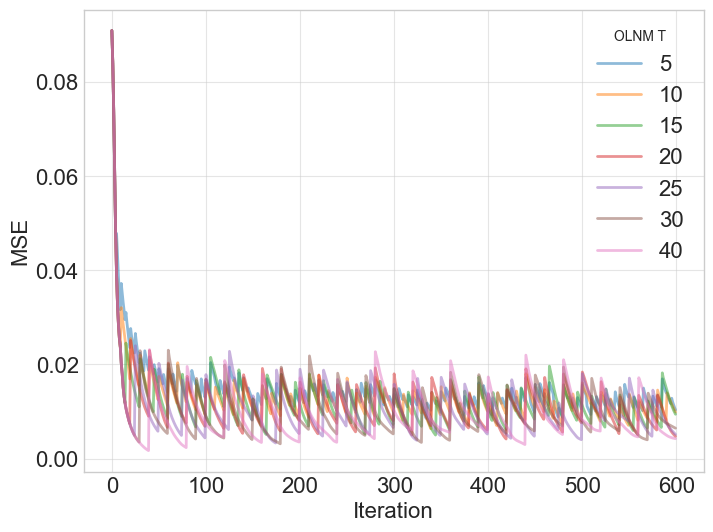

In [27]:
plot_histories(olnm_t_small, 'OLNM T', 'tuning_olnm_t_small', 
               window_size=1, alpha_special=True)

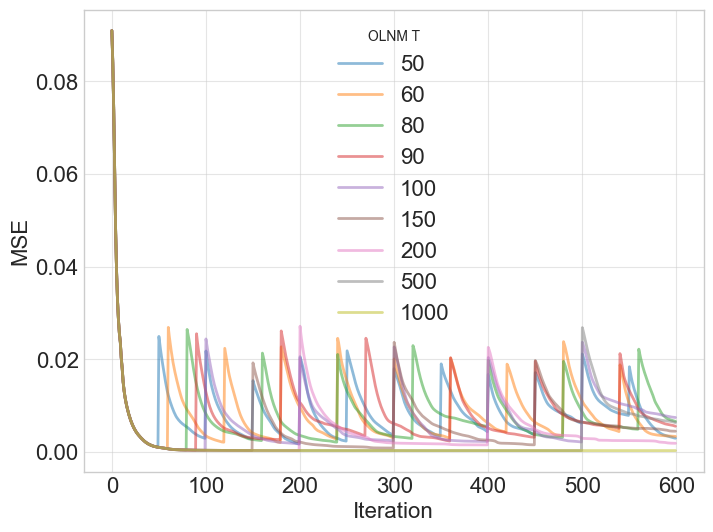

In [28]:
plot_histories(olnm_t, 'OLNM T', 'tuning_olnm_t', 
               window_size=1, alpha_special=True)